
# Interpretability Seminar

This notebook has two parts:

1. **Attention head visualisation** – we load a GPT‑2 model and visualise its attention patterns.  The goal is to identify phenomena such as attention sinks, copy/induction heads, and positional biases.
2. **Causal interventions and feature steering** – we perform activation patching on the Indirect Object Identification (IOI) task to locate where the model resolves pronoun reference, and we demonstrate simple feature steering through head ablation.

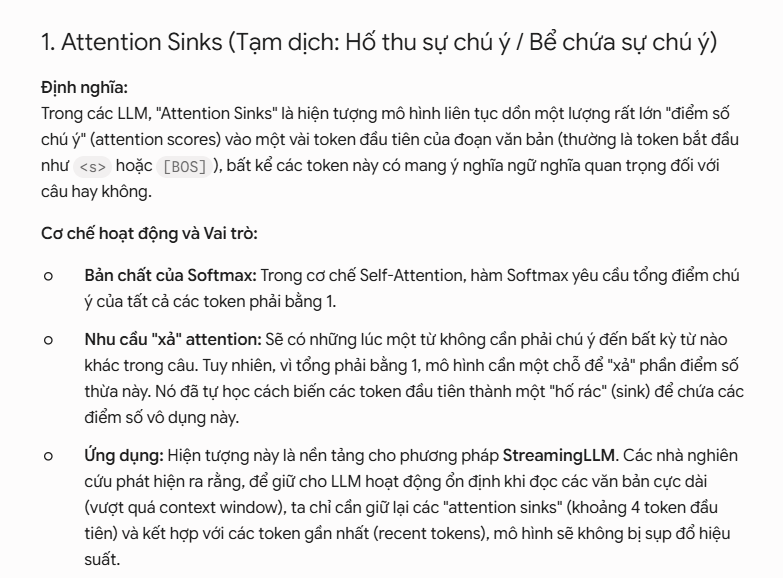

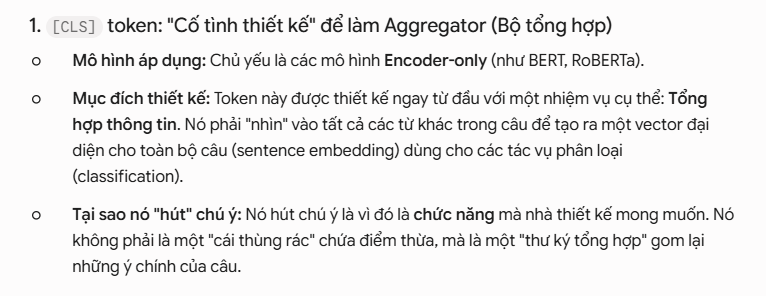

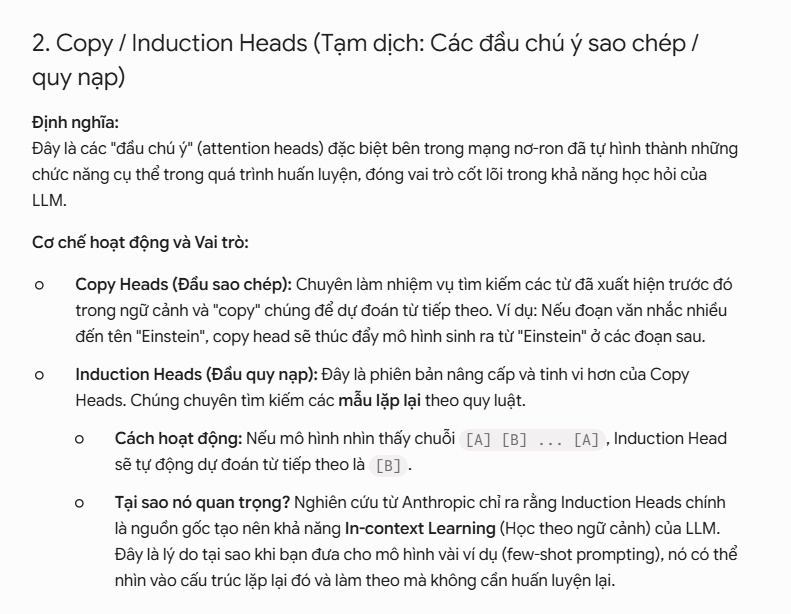

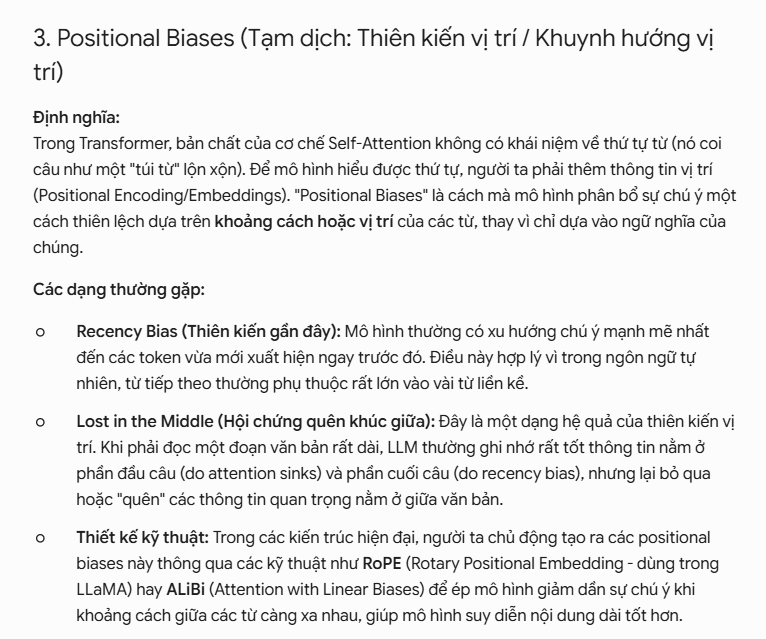

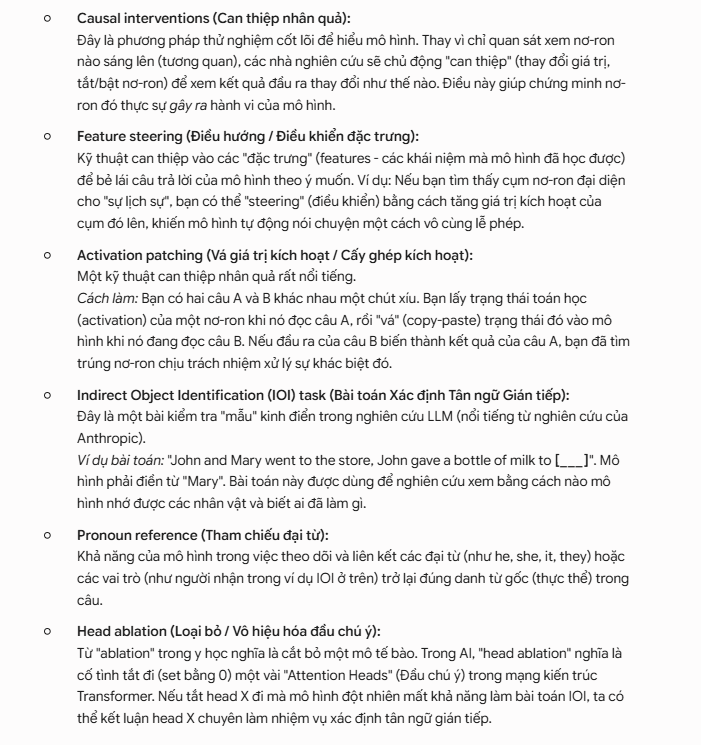

In [1]:
!pip install -q torch matplotlib transformer_lens transformers circuitsvis

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 101.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 28.4 MB/s eta 0:00:00


In [2]:
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer # Can thiệp, trích xuất dữ liệu từ các lớp bên trong mô hình AI, thường dùng khi muốn giải thích được model NLP
import transformers                          # Tải các mô hình ngôn ngữ và bộ tokenizer từ Hugging Face

import IPython.display as ipd                # Hiển thị giao diện, biểu đồ tương tác trên Jupyter Notebook/Colab
import circuitsvis as cv                     # Trực quan hóa cơ chế hoạt động của mô hình (vd: vẽ biểu đồ Attention)
model = HookedTransformer.from_pretrained("gpt2") # gọi dòng này tự động hiển thị print model luôn
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

/tmp/ipykernel_58/3338204917.py:8: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2") # gọi dòng này tự động hiển thị print model luôn


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint(name='hook_embed')
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint(name='hook_pos_embed')
  (blocks): TypedModuleList(
    (0): TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln1.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln1.hook_normalized')
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln2.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln2.hook_normalized')
      )
      (attn): Attention(
        (hook_k): HookPoint(name='blocks.0.attn.hook_k')
        (hook_q): HookPoint(name='blocks.0.attn.hook_q')
        (hook_v): HookPoint(name='blocks.0.attn.hook_v')
        (hook_z): HookPoint(name='blocks.0.attn.hook_z')
        (hook_attn_scores): HookPoint(name='blocks.0.attn.hook_attn_scores')
        (hook_pattern): HookPoint(name='blocks.0.attn.hook_pattern')
        (hook_result): HookPoint(name

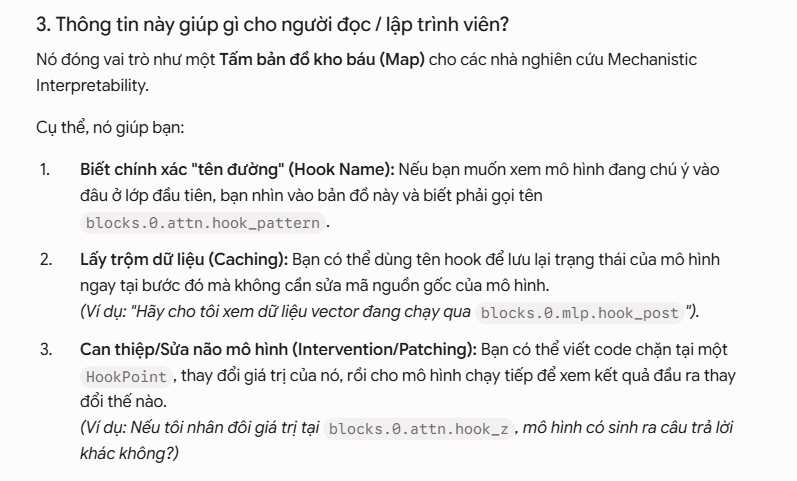

In [3]:
text = "When Mary and John went to the store, John gave a drink to"
model.generate(text)

  0%|          | 0/10 [00:00<?, ?it/s]

'When Mary and John went to the store, John gave a drink to them, and Mary drunk. Then she tied the'

In [4]:
def visualise_attention(layer):
    assert layer in list(range(12))
    _, cache = model.run_with_cache(tokens) # model.run_with_cache(): Đây là "phép thuật" chính của thư viện transformer_lens. Thay vì chỉ chạy mô hình để lấy kết quả cuối cùng, hàm này sẽ chạy mô hình và ghi lại toàn bộ dữ liệu đi qua tất cả các "camera giám sát" (HookPoint) bên trong nó.
    # thường kí tự đầu là logits, cache: Là một dạng từ điển (dictionary) khổng lồ chứa toàn bộ các trạng thái trung gian của mô hình mà ta vừa thu thập được.
    pattern = cache[f"blocks.{layer}.attn.hook_pattern"] # (batch, heads, Q_len, K_len)
    # heads: Số lượng "cái đầu" (Attention Heads) trong lớp đó (thường là 12 heads cho GPT-2 small).
    #Q_len (Query) & K_len (Key): Độ dài của câu. Nó tạo thành một ma trận vuông để so sánh chéo từng từ với mọi từ khác trong câu.
    str_tokens = model.to_str_tokens(tokens) # chuyển tokens dạng số thành dạng chữ dịch ngược lại
    a = cv.attention.attention_patterns(tokens=str_tokens, attention=pattern[0]) # attention=pattern[0]: Truyền ma trận số liệu vào. Sở dĩ có thêm [0] là để chọn câu đầu tiên (và duy nhất) trong cái batch. Nó sẽ gỡ bỏ chiều batch đi, chỉ truyền vào một tensor có dạng (heads, Q_len, K_len) để thư viện có thể vẽ chính xác 12 cái heads (12 hình vuông) của lớp (layer) đó.
    return a


text = "When Mary and John went to the store, John gave a drink to Mary."
tokens = model.to_tokens(text).to(device) # tương tự tokenize nhưng nó riêng hơn dùng trả về pytorch tensors cho mục đích tìm hiểu cơ chế hơn

layer = 0
ipd.display(visualise_attention(layer));

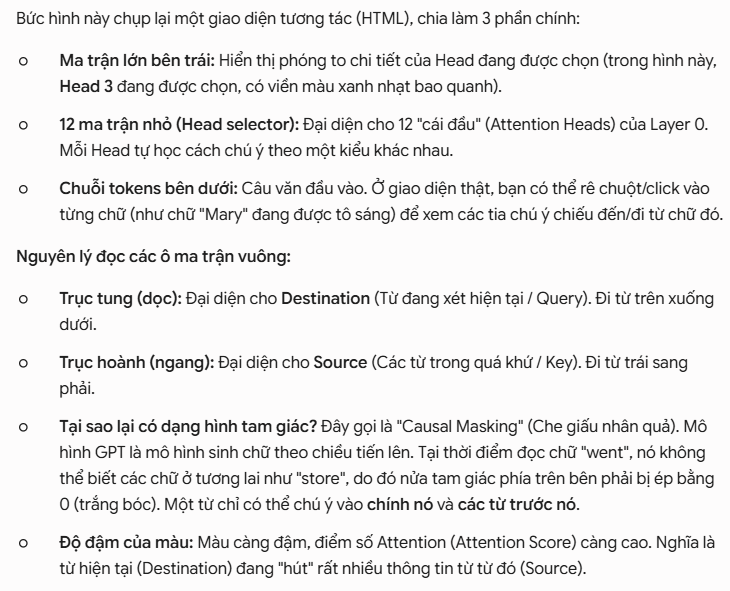

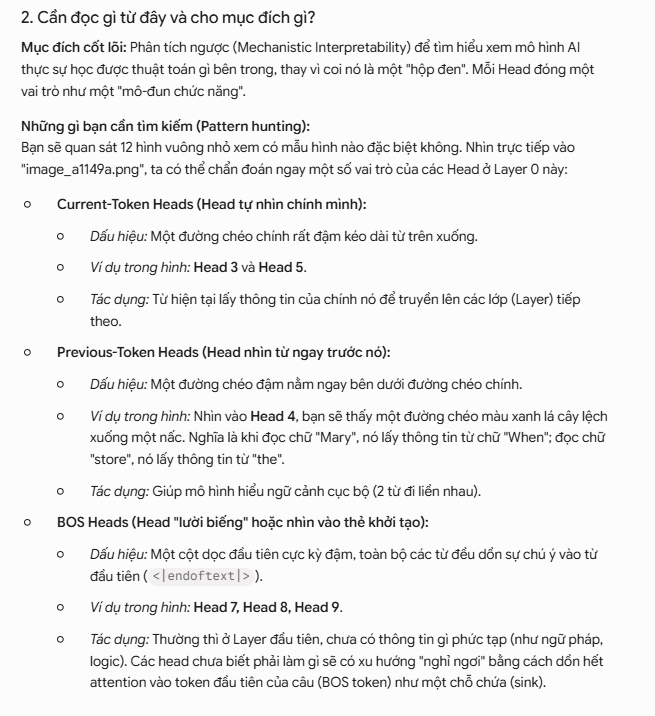

từ đó tìm ra thuật toán bên trong nó. Khi đã chẩn đoán được vai trò của các Head qua hình ảnh, các nhà nghiên cứu sẽ thực hiện các bước tiếp theo sau đây: 1. Cắt bỏ để kiểm chứng (Ablation / Pruning) 2. Cấy ghép và Tráo đổi "Ký ức" (Activation Patching) 3. Ghép nối thành một "Mạch thuật toán" (Circuit Discovery)

### Attention heads (1 point)
Your task is to find the following attention heads (and please plot corresponding attention pattern):
- The earliest that attend to first Mary while generating second *
- Attention sink head
- Positional-bias head
- Induction head
- Punctuation-tracking head

In [5]:
# Chạy forward pass với cache trên biến global
_, cache = model.run_with_cache(tokens)

# Sau đó chạy vòng lặp của bạn
for layer in range(model.cfg.n_layers):
    # average attention weight on token 0 across heads and positions
    # Lấy hook pattern cho layer hiện tại (shape: [batch=1, heads, Q_len, K_len])
    pattern = cache[f"blocks.{layer}.attn.hook_pattern"]
    # Tính trung bình trọng số attention vào token đầu tiên (key index 0)
    first_tok_attn = pattern[0, :, :, 0].mean().item()
    print(f"Layer {layer}: avg attention on first token = {first_tok_attn:.2f}")


Layer 0: avg attention on first token = 0.30
Layer 1: avg attention on first token = 0.42
Layer 2: avg attention on first token = 0.34
Layer 3: avg attention on first token = 0.53
Layer 4: avg attention on first token = 0.56
Layer 5: avg attention on first token = 0.75
Layer 6: avg attention on first token = 0.69
Layer 7: avg attention on first token = 0.84
Layer 8: avg attention on first token = 0.73
Layer 9: avg attention on first token = 0.80
Layer 10: avg attention on first token = 0.78
Layer 11: avg attention on first token = 0.67


### Attention heads (1 point)

Your task is to find the following attention heads (and please plot corresponding attention pattern):

---

#### 📌 Hướng dẫn và Dấu hiệu Nhận biết các Attention Heads:

##### ✅ 1. Attention Sink Head
*   **Nhiệm vụ:** Tìm Head thường dồn toàn bộ sự chú ý vào thẻ đầu tiên (`<|endoftext|>`) vì nó không biết phải làm gì, dùng thẻ đó làm "thùng rác" (sink) chứa điểm attention thừa.
*   **Dấu hiệu nhận biết:** Một cột dọc màu cực đậm sát viền bên trái của ma trận.
*   **Đáp án gợi ý:** **Layer 7, Head 2** (hoặc Layer 5 Head 1, Layer 8 Head 1). Tại Layer 0, các Head 7, 8, 9 cũng thể hiện tính chất này.

##### ✅ 2. Positional-bias Head
*   **Nhiệm vụ:** Tìm Head luôn chú ý vào một vị trí tương đối nhất định (ví dụ: luôn nhìn vào từ ngay sát trước nó, hoặc từ cách nó 2 khoảng).
*   **Dấu hiệu nhận biết:** Một đường chéo đậm nằm song song với đường chéo chính (bị lệch xuống 1 hoặc vài nấc).
*   **Đáp án gợi ý:** **Layer 4, Head 11** (Score 1.0, luôn nhìn vào từ đứng ngay trước nó). Tại Layer 0, Head 4 (Previous-token head) cũng có tính chất tương tự.

##### 🔍 3. Name Mover Head (The earliest that attend to first Mary while generating second *)
*   **Nhiệm vụ:** Tìm Head giúp mô hình nối chữ "Mary" ở cuối câu với chữ "Mary" ở đầu câu.
*   **Cách tìm:** Bạn chạy code quét ở các Layer cao (Layer 9 hoặc 10). Tìm hàng ngang ứng với vị trí từ `" to"` ở cuối câu (index 14) gióng sang ngang, nếu thấy điểm màu cực đậm rơi đúng vào cột dọc của chữ `" Mary"` đầu tiên (index 2) thì đó chính là nó.
*   **Dấu hiệu:** Một chấm màu đậm nằm lẻ loi ở góc dưới bên trái của ma trận.
*   **Đáp án gợi ý:** **Layer 9, Head 6** và **Layer 9, Head 9** (Positive Name Movers xuất hiện sớm nhất tại Layer 9).

##### 🔍 4. Induction Head
*   **Nhiệm vụ:** Tìm Head làm nhiệm vụ "nhớ mẫu" (Pattern matching). Luật của nó là: Nếu trước đây `[A]` đi liền với `[B]`, thì bây giờ thấy `[A]`, ta sẽ chú ý vào `[B]`. (Trong câu này: Thấy `"John"` đầu tiên đi với `"went"`, vậy khi thấy `"John"` thứ 2, nó sẽ nhìn vào `"went"`).
*   **Cách tìm & Dấu hiệu:** Xuất hiện ở các Layer trung bình (Layer 5 đến 7). Tìm hàng ngang của từ `"John"` thứ 2 (index 10), gióng sang ngang tìm điểm đậm rơi trúng vào cột của chữ `"went"` (index 5 - từ đi sau John đầu tiên).
*   **Đáp án gợi ý:** **Layer 5, Head 5** (Score 0.92, cực kỳ rõ nét) hoặc **Layer 5, Head 8**.

##### 🔍 5. Punctuation-tracking Head
*   **Nhiệm vụ:** Tìm Head chỉ quan tâm đến các dấu câu.
*   **Cách tìm:** Rất dễ nhận biết. Bạn tìm một Head có các cột dọc đậm rơi chính xác vào vị trí của dấu phẩy `,` và dấu chấm `.`.
*   **Đáp án gợi ý:** **Layer 2, Head 5** (Score 0.36) hoặc **Layer 1, Head 1**.


In [6]:
_, cache = model.run_with_cache(tokens)

import torch
str_tokens = model.to_str_tokens(tokens)
print("Tokens:", {i: t for i, t in enumerate(str_tokens)})
# text = "When Mary and John went to the store, John gave a drink to Mary."

mary_indices = [i for i, t in enumerate(str_tokens) if "Mary" in t]
john_indices = [i for i, t in enumerate(str_tokens) if "John" in t]
punc_indices = [i for i, t in enumerate(str_tokens) if "," in t or "." in t]

john_1_idx = john_indices[0]
went_idx = john_1_idx + 1
john_2_idx = john_indices[1]

sink_scores = []
prev_token_scores = []
name_mover_scores = []
induction_scores = []
punc_scores = []

for layer in range(model.cfg.n_layers):
    pattern = cache[f"blocks.{layer}.attn.hook_pattern"][0]
    seq_len = pattern.shape[-1]
    for head in range(model.cfg.n_heads):
        head_pat = pattern[head]
        
        # 1. Attention Sink
        sink_score = head_pat[:, 0].mean().item()
        sink_scores.append((layer, head, sink_score))
        
        # 2. Positional Bias (Previous token)
        prev_score = sum(head_pat[q, q-1].item() for q in range(1, seq_len)) / (seq_len - 1)
        prev_token_scores.append((layer, head, prev_score))
        
        # 3. Name Mover (Query 'to' (idx 14) -> Key 'Mary' (idx 2))
        if len(mary_indices) >= 2:
            nm_score = head_pat[mary_indices[1] - 1, mary_indices[0]].item()
            name_mover_scores.append((layer, head, nm_score))
            
        # 4. Induction (Query 'John' (idx 10) -> Key 'went' (idx 5))
        ind_score = head_pat[john_2_idx, went_idx].item()
        induction_scores.append((layer, head, ind_score))
        
        # 5. Punctuation Tracking
        punc_score = 0.0
        punc_count = 0
        for p in punc_indices:
            for q in range(p + 1, seq_len):
                punc_score += head_pat[q, p].item()
                punc_count += 1
        if punc_count > 0:
            punc_score /= punc_count
        punc_scores.append((layer, head, punc_score))

def print_top(name, scores, limit=3):
    scores.sort(key=lambda x: x[2], reverse=True)
    print(f"\n--- Top {limit} for {name} ---")
    for i in range(limit):
        layer, head, val = scores[i]
        print(f"Rank {i+1}: Layer {layer}, Head {head} | Score: {val:.4f}")

print_top("Attention Sink", sink_scores)
print_top("Positional Bias (Previous Token)", prev_token_scores)
print_top("Name Mover Head (S2_prev -> S1)", name_mover_scores)
print_top("Induction Head (A2 -> B1)", induction_scores)
print_top("Punctuation Tracking Head", punc_scores)

def plot_single_head(layer, head_index, text=text):
    tokens_plot = model.to_tokens(text).to(device)
    _, cache_plot = model.run_with_cache(tokens_plot)
    pattern = cache_plot[f"blocks.{layer}.attn.hook_pattern"]
    str_tokens = model.to_str_tokens(tokens_plot)
    single_head_pattern = pattern[0, head_index : head_index + 1]
    print(f"Hiển thị biểu đồ: Layer {layer} | Head {head_index}")
    return cv.attention.attention_patterns(tokens=str_tokens, attention=single_head_pattern)


Tokens: {0: '<|endoftext|>', 1: 'When', 2: ' Mary', 3: ' and', 4: ' John', 5: ' went', 6: ' to', 7: ' the', 8: ' store', 9: ',', 10: ' John', 11: ' gave', 12: ' a', 13: ' drink', 14: ' to', 15: ' Mary', 16: '.'}

--- Top 3 for Attention Sink ---
Rank 1: Layer 7, Head 2 | Score: 0.9949
Rank 2: Layer 5, Head 1 | Score: 0.9934
Rank 3: Layer 8, Head 1 | Score: 0.9706

--- Top 3 for Positional Bias (Previous Token) ---
Rank 1: Layer 4, Head 11 | Score: 1.0000
Rank 2: Layer 2, Head 2 | Score: 0.5567
Rank 3: Layer 3, Head 7 | Score: 0.4206

--- Top 3 for Name Mover Head (S2_prev -> S1) ---
Rank 1: Layer 10, Head 7 | Score: 0.8249
Rank 2: Layer 9, Head 6 | Score: 0.6719
Rank 3: Layer 9, Head 9 | Score: 0.6651

--- Top 3 for Induction Head (A2 -> B1) ---
Rank 1: Layer 5, Head 5 | Score: 0.9174
Rank 2: Layer 5, Head 8 | Score: 0.6882
Rank 3: Layer 6, Head 3 | Score: 0.3014

--- Top 3 for Punctuation Tracking Head ---
Rank 1: Layer 2, Head 5 | Score: 0.3567
Rank 2: Layer 1, Head 1 | Score: 0.2474

In [13]:
ipd.display(visualise_attention(4)); #  Positional Bias

In [15]:
ipd.display(visualise_attention(10)); # Name Mover Head

In [16]:
ipd.display(visualise_attention(5));# Induction Head

In [17]:
ipd.display(visualise_attention(2));# Punctuation Tracking Head, ở đây thấy được tập trung vào cột dấu , dù là từ nào ở phía sau


## Activation Patching and Feature Steering (2 points total)

Activation patching is *causal interventions* technique: run the model on a clean input (which exhibits correct behaviour) and a corrupted input (which exhibits incorrect behaviour), then replace a component of the corrupted run with the corresponding activation from the clean run.  If the model’s output is “fixed” by the patch, the replaced component is causal for the behaviour.

In [7]:
# IOI prompts
ioi_clean = "After John and Mary went to the store, Mary gave a bottle of milk to"
ioi_corrupt = "After John and Mary went to the store, John gave a bottle of milk to"
print(torch.where(model.to_tokens(ioi_clean) != model.to_tokens(ioi_corrupt))[1])

tensor([10], device='cuda:0')


In [8]:
clean_tokens = model.to_tokens(ioi_clean).to(device)
corrupt_tokens = model.to_tokens(ioi_corrupt).to(device)

# Utility to compute logit difference between " John" and " Mary"
def logits_to_logit_diff(logits): # tính điểm ra john là câu clean (john cho từ tiếp theo)
    john_id = model.to_single_token(" John")
    mary_id = model.to_single_token(" Mary")
    final_logits = logits[0, -1, :]
    return float(final_logits[john_id] - final_logits[mary_id])

# Baseline predictions
clean_logits = model(clean_tokens)
corrupt_logits = model(corrupt_tokens)
print("Clean prompt logit diff (John vs Mary):", logits_to_logit_diff(clean_logits))
print("Corrupt prompt logit diff (John vs Mary):", logits_to_logit_diff(corrupt_logits))


Clean prompt logit diff (John vs Mary): 4.276431083679199
Corrupt prompt logit diff (John vs Mary): -2.737590789794922


/tmp/ipykernel_58/3805381939.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(final_logits[john_id] - final_logits[mary_id])


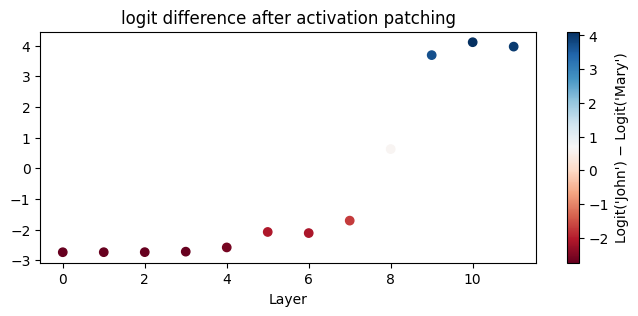

In [9]:
_, clean_cache = model.run_with_cache(clean_tokens)
_, corrupt_cache = model.run_with_cache(corrupt_tokens)

layers = model.cfg.n_layers
logit_diff_effect = torch.zeros((layers, 1))

pos = 10 # vị trí token thứ 10
for L in range(layers):
    
    #Hàm patch_resid_hook (Điểm cốt lõi): Đây là hàm "đánh tráo". Khi mô hình đang chạy đến layer L, hàm này sẽ can thiệp vào residual stream (luồng dữ liệu chính của Transformer). Nó lấy dữ liệu trung gian tại token số 10 của câu "nhiễu" (corrupt_cache) đè lên dữ liệu của câu "sạch" (resid).
    # Hook function to replace the residual stream at (layer L)
    def patch_resid_hook(resid, hook, position=pos, layer=L):
        # Thay thế activation của prompt sạch bằng prompt bị lỗi tại vị trí index chỉ định
        resid[:, position, :] = corrupt_cache[hook.name][:, position, :]
        return resid

    # Run corrupted prompt with the hook
    # Ý nghĩa: Chúng ta đang hỏi mô hình: "Nếu tôi giữ nguyên mọi thứ hoàn hảo, nhưng chỉ chọc phá (làm nhiễu) thông tin tại đúng token 10 của layer L, thì kết quả dự đoán cuối cùng của bạn có bị sai lệch không?"
    patched_logits = model.run_with_hooks( # run_with_hooks: Mô hình được chạy lại với đầu vào "sạch" (clean_tokens). Tuy nhiên, khi đến ngay trước layer L (hook_resid_pre), hàm đánh tráo ở trên sẽ được kích hoạt.
        clean_tokens,
        fwd_hooks=[(f"blocks.{L}.hook_resid_pre", patch_resid_hook)]
    )

    # Measure logit difference after patching
    logit_diff_effect[L] = logits_to_logit_diff(patched_logits)

plt.figure(figsize=(8, 3))
plt.scatter(range(12), logit_diff_effect.squeeze().numpy(), cmap='RdBu', c=logit_diff_effect)
plt.colorbar(label="Logit('John') − Logit('Mary')")
plt.xlabel("Layer")
plt.title("logit difference after activation patching")
plt.show()


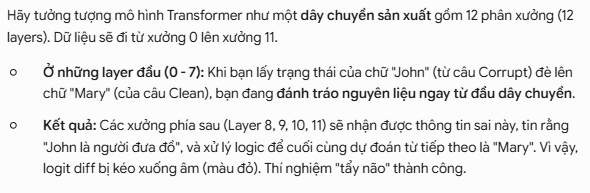

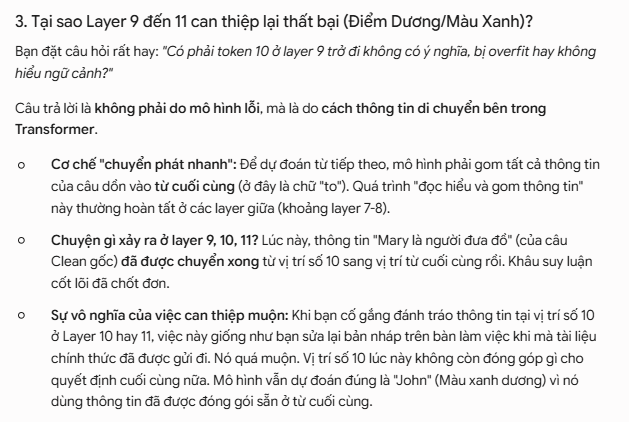

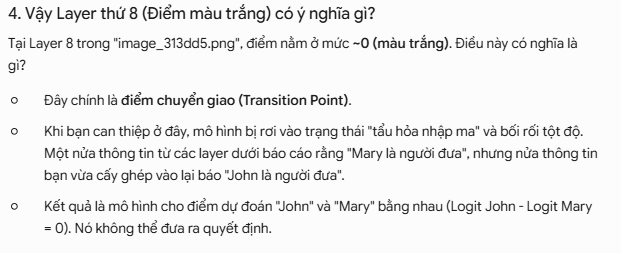

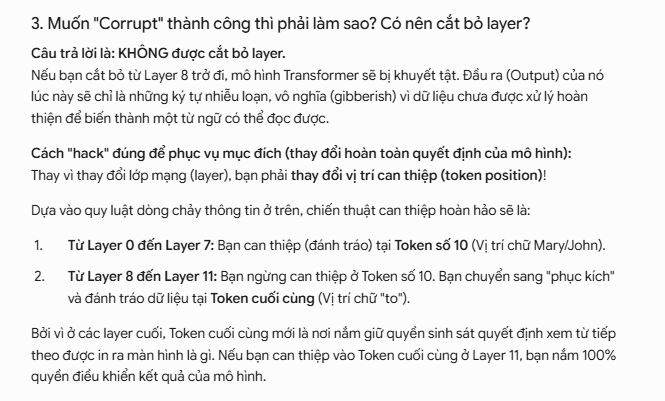

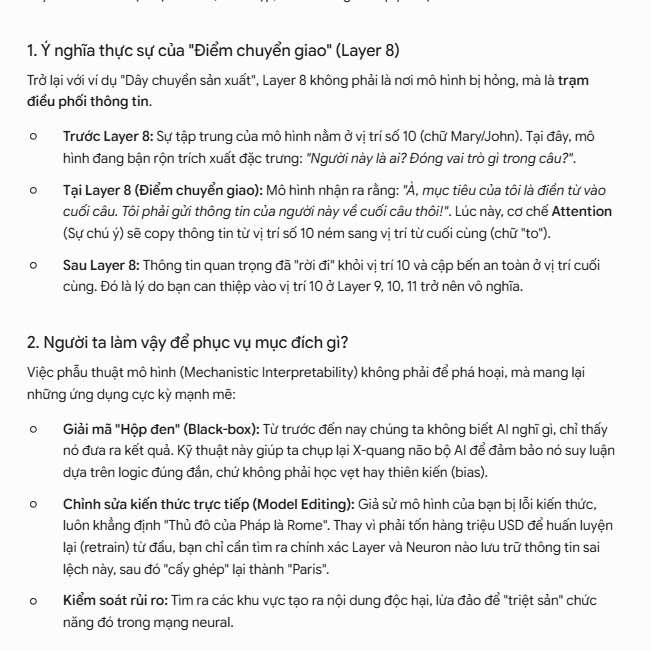


### Feature steering via head ablation (1 point)

Once we have identified a head or layer that contributes to a behaviour, we can *steer* the model by intervening on it.  For example, ablation removes a head’s influence by zeroing its output.  Conversely, we could amplify a head’s output to bias the model.


In [10]:
def generate_with_hooks(model: HookedTransformer, prompt: str, max_new_tokens: int, hooks)-> str: 
    tokens = model.to_tokens(prompt)
    tokens = tokens.to(model.cfg.device)

    for _ in range(max_new_tokens):
        logits = model.run_with_hooks(
            tokens,
            fwd_hooks=hooks
        )
        next_token = logits[0, -1].argmax().unsqueeze(0)
        tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)

        if next_token == model.tokenizer.eos_token_id:
            break

    return model.to_string(tokens[0, 1:])

# Định nghĩa generate_completion để gọi lúc không dùng hooks
def generate_completion(prompt: str, max_new_tokens: int = 20) -> str:
    return generate_with_hooks(model, prompt, max_new_tokens, hooks=[])

def ablate_heads(model: HookedTransformer, heads, prompt: str, max_new_tokens: int = 20)-> str:
    # 1. Gom nhóm các heads cần can thiệp theo từng layer (lớp)
    # Ví dụ input heads = [(0, 4), (0, 7), (1, 2)] (nghĩa là tắt head 4 và 7 ở layer 0, head 2 ở layer 1)
    by_layer = {}
    for layer, head_idx in heads:
        # setdefault giúp tạo list rỗng nếu layer chưa có trong dict, sau đó thêm head_idx vào
        # Kết quả by_layer = {0: [4, 7], 1: [2]}
        by_layer.setdefault(layer, []).append(head_idx)
    
    hooks = []
    
    # 2. Duyệt qua từng layer để tạo hook tương ứng
    for layer, head_list in by_layer.items():

        # Cần dùng hàm bọc (closure) make_hook và gán head_list=head_list 
        # để tránh lỗi "late binding" (nhận sai giá trị của vòng lặp cuối cùng) trong Python
        def make_hook(head_list=head_list):
            
            # Đây là hàm hook thực sự sẽ được TransformerLens gọi khi mô hình chạy
            # Biến 'v' (Value) là ma trận chứa các đặc trưng của từ trước khi nhân với Attention Score
            # Biến 'hook' chứa metadata về vị trí của hook này trong mô hình
            def hook(v, hook):
                
                # --- GIẢI THÍCH VỀ SHAPE CỦA TENSOR 'v' ---
                # v là một Pytorch Tensor có shape 4 chiều: [batch, position, head_index, d_head]
                # - Chiều 0: batch (số lượng câu đang xử lý cùng lúc. Thường là 1 khi generate)
                # - Chiều 1: position (số lượng token/từ của câu tính đến hiện tại)
                # - Chiều 2: head_index (tổng số lượng Attention Head trong 1 layer, ví dụ 12)
                # - Chiều 3: d_head (số chiều của mỗi head, ví dụ 64)
                
                # CÚ PHÁP CẮT TENSOR (SLICING):
                # CHỈ LẤY các head nằm trong danh sách head_list (ví dụ [4, 7])
                # Ở TẤT CẢ các chiều của head đó (:)
                # => Gán toàn bộ giá trị của phần này bằng 0.0 (Vô hiệu hóa hoàn toàn head này)
                v[:, :, head_list, :] = 0.0
                
                # Trả về ma trận 'v' sau khi đã bị chỉnh sửa để mô hình tiếp tục tính toán
                return v
            
            return hook # Trả về cái hàm hook vừa định nghĩa

        # 3. Đăng ký hook vào đúng vị trí của mô hình
        # "blocks.{layer}.attn.hook_v" là tên vị trí đầu ra của ma trận Value (V) trong khối Attention
        hooks.append((f"blocks.{layer}.attn.hook_v", make_hook()))

    return generate_with_hooks(
        model,
        prompt,
        max_new_tokens=max_new_tokens,
        hooks=hooks
    )


def scale_heads(model: HookedTransformer, heads, scale, prompt: str, max_new_tokens: int = 20)-> str:
    by_layer = {}
    for layer, head_idx in heads:
        by_layer.setdefault(layer, []).append(head_idx)
    hooks = []
    for layer, head_list in by_layer.items():

        def make_hook(head_list=head_list):
            def hook(v, hook):
                # scaling outputs of all hooked heads by scale
                # v có shape: [batch, position, head_index, d_head]
                v[:, :, head_list, :] *= scale
                return v
            return hook

        hooks.append((f"blocks.{layer}.attn.hook_v", make_hook()))

    return generate_with_hooks(
        model,
        prompt,
        max_new_tokens=max_new_tokens,
        hooks=hooks
    )

In [11]:

ioi_prompt = "After John and Mary went to the store, Mary gave a bottle of milk to"
max_new_tokens = 10
#tự tiềm kiếm từ bước tìm head trước sau đó cho thử qua các phương pháp cắt giảm thay đổi head 
NAME_MOVER = [(9,6), (9,9), (10,0)]
NEG_NM     = [(10,7), (11,10)]

print(generate_completion(ioi_prompt, max_new_tokens=max_new_tokens))
print(ablate_heads(model, NAME_MOVER, ioi_prompt, max_new_tokens=max_new_tokens))
print(scale_heads(model, NEG_NM, 7.0, ioi_prompt, max_new_tokens=max_new_tokens))

After John and Mary went to the store, Mary gave a bottle of milk to John. John said, "John, I'm
After John and Mary went to the store, Mary gave a bottle of milk to John. John said, "I don't know
After John and Mary went to the store, Mary gave a bottle of milk to the Buddha.

"I'll tell you


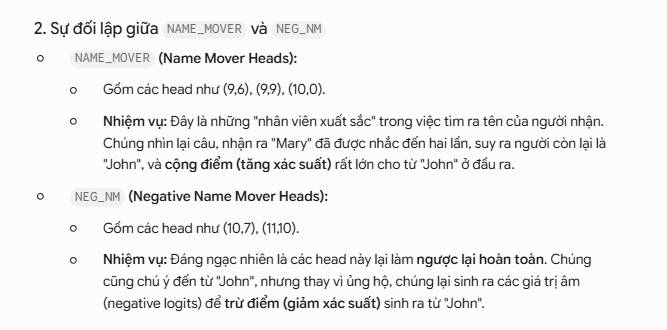

### You may want to experiment here a bit and find more robust setup (for bonus points)
Here are papers that might help you: \
https://arxiv.org/pdf/2211.00593 \
https://arxiv.org/pdf/2310.04625 
